In [5]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [6]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df('D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Irritation\Dataset/tes_set_skin_irritation_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
  Outcome RowID                                 Morgan_Descriptors  \
0       1   185  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...   
1       0   297  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       0   515  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0   299  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...   
4       0   464  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.33546491193985767, -1.0152756893381816, -0...  185   
1  [3.661806524504995, 0.8355237457375205, 0.9019...  297   
2  [-1.0952040855758334, -1.890792479825778

In [7]:
test_df.keys()

Index(['Outcome', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'],
      dtype='object

In [8]:
test_df
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

In [9]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df.head(100)

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
110,0,361,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5441383428952367, 0.12383288877765863, 0.17...",361,CC(CN=Cc1ccccc1O)N=Cc1ccccc1O,282.136827816,3.0243000000000015,123.69232037365632,...,2.0,3.0,6.0,0.4615384615384615,5.0,0.0,65.18,5.459431618637297,3.3560000000000008,0.1764705882352941
35,0,517,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.24689294768837985, 0.3055417593701029, 0.3...",517,CCO[Si](CCCCl)(OCC)OCC,240.09484874199998,2.6637000000000013,93.0536626905066,...,0.0,3.0,8.0,0.4285714285714285,9.0,0.0,27.69,4.700439718141093,3.011,1.0
73,0,302,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0139889980949837, 0.9794352606285356, 1.048...",302,O=[N+]([O-])c1cc(S(=O)(=O)Nc2ccccc2)ccc1Nc1ccccc1,369.07832696,4.139200000000002,150.059067513756,...,2.0,0.0,3.0,0.5,6.0,0.0,109.72,5.807354922057604,4.677000000000001,0.0
38,0,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0....",377,Nc1cc(C(=O)O)cc(C(=O)O)c1,181.037507704,0.6652000000000002,73.41268974978244,...,3.0,0.0,3.0,0.3333333333333333,2.0,0.0,100.62000000000002,4.700439718141093,0.435,0.0
39,0,300,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2279963519826929, 1.2210145101180618, 1.292...",300,CS(=O)(=O)c1ccc(C(O)=C2C(=O)CCCC2=O)c(Cl)c1COC...,442.085301756,3.030300000000002,174.11236040177238,...,1.0,0.0,3.0,0.4615384615384615,6.0,0.0,115.35,5.954196310386876,2.755,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,173,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.289469593552933, -1.2598966808627081, -1.22...",173,CCCCCCCCCCCCCCCCCCN,269.308250248,6.206600000000005,122.28315766958464,...,1.0,18.0,19.0,0.5,16.0,2.0,26.02,5.169925001442312,8.75,1.0
68,1,175,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207184, -1.1381678094099636, -1....",175,CCCCCC(=O)CC,128.120115132,2.5458000000000007,57.455367928649565,...,0.0,8.0,8.0,0.4285714285714285,5.0,0.0,17.07,4.0,2.398,0.875
66,1,21,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.150213701202547, -1.180345219322451, -1.143...",21,CC(C)CCCCCCCCCCOCCCN,257.27186474,4.518700000000003,114.66681867029831,...,1.0,12.0,17.0,0.5,14.0,2.0,35.25,5.08746284125034,6.011999999999998,1.0
65,1,183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2407834604588776, 0.1020663565749143, 0.15...",183,CCOP(OCC)c1ccccc1,198.08096635,2.6968000000000005,80.79128793322488,...,0.0,2.0,7.0,0.4285714285714285,5.0,0.0,32.05,4.700439718141093,2.484,0.4


Classes                          :  ['0' '1']
Number of cpds in each class     :  [63, 48]
Total number of cpds             :  111
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

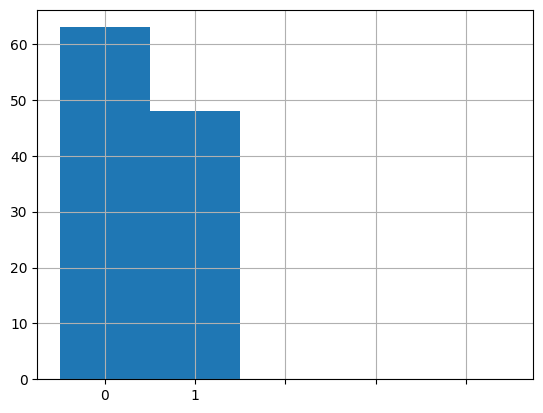

In [10]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


#GRAPH
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [11]:
test_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
110,0,361,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5441383428952367, 0.12383288877765863, 0.17...",361,CC(CN=Cc1ccccc1O)N=Cc1ccccc1O,282.136827816,3.0243000000000015,123.69232037365632,...,2.0,3.0,6.0,0.4615384615384615,5.0,0.0,65.18,5.459431618637297,3.3560000000000008,0.1764705882352941
35,0,517,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.24689294768837985, 0.3055417593701029, 0.3...",517,CCO[Si](CCCCl)(OCC)OCC,240.09484874199998,2.6637000000000013,93.0536626905066,...,0.0,3.0,8.0,0.4285714285714285,9.0,0.0,27.69,4.700439718141093,3.011,1.0
73,0,302,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0139889980949837, 0.9794352606285356, 1.048...",302,O=[N+]([O-])c1cc(S(=O)(=O)Nc2ccccc2)ccc1Nc1ccccc1,369.07832696,4.139200000000002,150.059067513756,...,2.0,0.0,3.0,0.5,6.0,0.0,109.72,5.807354922057604,4.677000000000001,0.0
38,0,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0....",377,Nc1cc(C(=O)O)cc(C(=O)O)c1,181.037507704,0.6652000000000002,73.41268974978244,...,3.0,0.0,3.0,0.3333333333333333,2.0,0.0,100.62000000000002,4.700439718141093,0.435,0.0
39,0,300,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2279963519826929, 1.2210145101180618, 1.292...",300,CS(=O)(=O)c1ccc(C(O)=C2C(=O)CCCC2=O)c(Cl)c1COC...,442.085301756,3.030300000000002,174.11236040177238,...,1.0,0.0,3.0,0.4615384615384615,6.0,0.0,115.35,5.954196310386876,2.755,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,1,114,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0770944714823878, -2.462812673628373, -2.4...",114,CCSCC,90.05032132,1.7593999999999999,37.95718739638461,...,0.0,2.0,5.0,0.5,2.0,0.0,25.3,3.0,2.027,1.0
51,1,95,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4498042218684691, 0.053474178174383546, 0....",95,CCO[Si](C)(CCCCl)OCC,210.08428405799998,2.760300000000001,81.45184681769484,...,0.0,3.0,8.0,0.4285714285714285,7.0,0.0,18.46,4.459431618637298,3.0640000000000005,1.0
49,1,121,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45129859089487834, 0.3586465302534612, 0.4...",121,O=CC1=C(Cl)C(C=O)CCC1,172.029107208,1.6772,70.22472206986153,...,0.0,0.0,2.0,0.5,2.0,0.0,34.14,4.459431618637298,0.987,0.5
61,1,178,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7374636254485172, -0.29732112150646445, -0...",178,O=C1COC(=O)CO1,116.01095860800001,-0.9136,45.37838087659143,...,0.0,0.0,0.0,0.4,0.0,0.0,52.60000000000001,4.0,-0.5939999999999999,0.5


In [12]:
x_rdkitcdk = test_df.drop(columns=['Outcome', 'RowID', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',])

print(x_rdkitcdk)

              LabuteASA                TPSA                 AMW  \
110  123.69232037365632               65.18             282.343   
35     93.0536626905066               27.69  240.80299999999994   
73     150.059067513756              101.34   369.4020000000001   
38    73.41268974978244  100.62000000000002             181.147   
39   174.11236040177238              106.97   442.9170000000003   
..                  ...                 ...                 ...   
53    37.95718739638461                 0.0              90.191   
51    81.45184681769484               18.46  210.77699999999996   
49    70.22472206986153               34.14  172.61099999999993   
61    45.37838087659143   52.60000000000001  116.07199999999999   
55   54.489316594191685               52.32             129.159   

    NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
110              4              2                 5      2      4   
35               3              0                 9      

In [13]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

    Outcome RowID                                 Morgan_Descriptors  \
110       0   361  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
35        0   517  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73        0   302  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
38        0   377  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
39        0   300  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..      ...   ...                                                ...   
53        1   114  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
51        1    95  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
49        1   121  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
61        1   178  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
55        1   260  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                     MACCS_Descriptors  \
110  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
35   [0, 0, 0, 0, 0

In [14]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [16]:
x_test_rdkit_cdk

array([['123.69232037365632', '65.18', '282.343', ...,
        '5.459431618637297', '3.3560000000000008', '0.1764705882352941'],
       ['93.0536626905066', '27.69', '240.80299999999994', ...,
        '4.700439718141093', '3.011', '1.0'],
       ['150.059067513756', '101.34', '369.4020000000001', ...,
        '5.807354922057604', '4.677000000000001', '0.0'],
       ...,
       ['70.22472206986153', '34.14', '172.61099999999993', ...,
        '4.459431618637298', '0.987', '0.5'],
       ['45.37838087659143', '52.60000000000001', '116.07199999999999',
        ..., '4.0', '-0.5939999999999999', '0.5'],
       ['54.489316594191685', '52.32', '129.159', ..., '4.0', '0.389',
        '0.5']], dtype=object)

In [17]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [18]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [21]:
# === LOAD MODEL ===
import joblib
import pickle

# Path direktori model
descriptor_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Irritation\Model\Descriptor"
phys_path       = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Irritation\Model\Physiochemical"

# ----------- DESKRIPTOR -----------
rf_morgan  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_RF_morgan.pkl")
rf_maccs   = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_RF_maccskey.pkl")
rf_modred  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_RF_modred.pkl")

svm_morgan = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_SVM_morgan.pkl")
svm_maccs  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_SVM_maccskey.pkl")
svm_modred = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_SVM_modred.pkl")

xgb_morgan = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_XGB_morgan.pkl")
xgb_maccs  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_XGB_maccskey.pkl")
xgb_modred = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_XGB_modred.pkl")

nn_morgan  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_NN_morgan.pkl")
nn_maccs   = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_NN_maccskey.pkl")
nn_modred  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_NN_modred.pkl")

lgbm_morgan = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_LGBM_morgan.pkl")
lgbm_maccs  = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(f"{descriptor_path}\\Model_Skin Irr_toxicity_LGBM_modred.pkl")

# ----------- FISIOKIMIA -----------
rf_p   = joblib.load(f"{phys_path}\\Model_Skin Irr_toxicity_RF_rdkit_cdk.pkl")
svm_p  = joblib.load(f"{phys_path}\\Model_Skin Irr_toxicity_SVM_rdkit_cdk.pkl")
xgb_p  = joblib.load(f"{phys_path}\\Model_Skin Irr_toxicity_XGB_rdkit_cdk.pkl")
nn_p   = joblib.load(f"{phys_path}\\Model_Skin Irr_toxicity_NN_rdkit_cdk.pkl")
lgbm_p = joblib.load(f"{phys_path}\\Model_Skin Irr_toxicity_LGBM_rdkit_cdk.pkl")


In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [23]:
x_test


array([[ 0.        ,  1.        ,  0.        , ...,  0.46731815,
         0.05595684,  0.43243787],
       [ 0.        ,  0.        ,  0.        , ..., -0.35169815,
        -0.08804313, -0.02343828],
       [ 0.        ,  0.        ,  0.        , ...,  1.1578613 ,
         0.54474545,  0.8103352 ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.39987558,
        -0.59305708, -0.46731768],
       [ 0.        ,  0.        ,  0.        , ..., -0.7049993 ,
        -0.99057811, -0.85121338],
       [ 0.        ,  0.        ,  0.        , ..., -0.75317673,
        -0.47947965, -0.62327531]])

In [24]:
test_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,rdkit_cdk
110,0,361,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5441383428952367, 0.12383288877765863, 0.17...",361,CC(CN=Cc1ccccc1O)N=Cc1ccccc1O,282.136827816,3.0243000000000015,123.69232037365632,...,3.0,6.0,0.4615384615384615,5.0,0.0,65.18,5.459431618637297,3.3560000000000008,0.1764705882352941,"[123.69232037365632, 65.18, 282.343, 4, 2, 5, ..."
35,0,517,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.24689294768837985, 0.3055417593701029, 0.3...",517,CCO[Si](CCCCl)(OCC)OCC,240.09484874199998,2.6637000000000013,93.0536626905066,...,3.0,8.0,0.4285714285714285,9.0,0.0,27.69,4.700439718141093,3.011,1.0,"[93.0536626905066, 27.69, 240.80299999999994, ..."
73,0,302,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0139889980949837, 0.9794352606285356, 1.048...",302,O=[N+]([O-])c1cc(S(=O)(=O)Nc2ccccc2)ccc1Nc1ccccc1,369.07832696,4.139200000000002,150.059067513756,...,0.0,3.0,0.5,6.0,0.0,109.72,5.807354922057604,4.677000000000001,0.0,"[150.059067513756, 101.34, 369.4020000000001, ..."
38,0,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0....",377,Nc1cc(C(=O)O)cc(C(=O)O)c1,181.037507704,0.6652000000000002,73.41268974978244,...,0.0,3.0,0.3333333333333333,2.0,0.0,100.62000000000002,4.700439718141093,0.435,0.0,"[73.41268974978244, 100.62000000000002, 181.14..."
39,0,300,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2279963519826929, 1.2210145101180618, 1.292...",300,CS(=O)(=O)c1ccc(C(O)=C2C(=O)CCCC2=O)c(Cl)c1COC...,442.085301756,3.030300000000002,174.11236040177238,...,0.0,3.0,0.4615384615384615,6.0,0.0,115.35,5.954196310386876,2.755,0.5,"[174.11236040177238, 106.97, 442.9170000000003..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53,1,114,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0770944714823878, -2.462812673628373, -2.4...",114,CCSCC,90.05032132,1.7593999999999999,37.95718739638461,...,2.0,5.0,0.5,2.0,0.0,25.3,3.0,2.027,1.0,"[37.95718739638461, 0.0, 90.191, 1, 0, 2, 0, 1..."
51,1,95,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4498042218684691, 0.053474178174383546, 0....",95,CCO[Si](C)(CCCCl)OCC,210.08428405799998,2.760300000000001,81.45184681769484,...,3.0,8.0,0.4285714285714285,7.0,0.0,18.46,4.459431618637298,3.0640000000000005,1.0,"[81.45184681769484, 18.46, 210.77699999999996,..."
49,1,121,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45129859089487834, 0.3586465302534612, 0.4...",121,O=CC1=C(Cl)C(C=O)CCC1,172.029107208,1.6772,70.22472206986153,...,0.0,2.0,0.5,2.0,0.0,34.14,4.459431618637298,0.987,0.5,"[70.22472206986153, 34.14, 172.61099999999993,..."
61,1,178,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7374636254485172, -0.29732112150646445, -0...",178,O=C1COC(=O)CO1,116.01095860800001,-0.9136,45.37838087659143,...,0.0,0.0,0.4,0.0,0.0,52.60000000000001,4.0,-0.5939999999999999,0.5,"[45.37838087659143, 52.60000000000001, 116.071..."


In [25]:
# CONSENSUS PHYSICOCHEMICAL
# phys only with all model include
# (RF + SVM + XGB + NN + LGBM)

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Assign correct data and initiate

x_phys = x_test_rdkit_cdk
y_true = y_true.values if hasattr(y_true, "values") else y_true

# Evaluation Function

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Predict probabilities

probs_rf   = rf_p.predict_proba(x_phys)[:, 1]
probs_svm  = svm_p.predict_proba(x_phys)[:, 1]
probs_xgb  = xgb_p.predict_proba(x_phys)[:, 1]
probs_nn   = nn_p.predict_proba(x_phys)[:, 1]
probs_lgbm = lgbm_p.predict_proba(x_phys)[:, 1]

# STACK ALL MODEL PROBABILITIES

all_model_probs = np.vstack([
    probs_rf,
    probs_svm,
    probs_xgb,
    probs_nn,
    probs_lgbm
])

# FINAL CONSENSUS (MEAN)

consensus_physicochemical_probs = all_model_probs.mean(axis=0)

# EVALUATION
consensus_metrics = evaluate_model(
    y_true,
    consensus_physicochemical_probs
)

print("\CONSENSUS PHYSICOCHEMICAL (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_metrics.items():
    print(f"{k}: {v}")


\CONSENSUS PHYSICOCHEMICAL (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[49 14]
 [10 38]]
Accuracy: 0.7837837837837838
AUC: 0.8485449735449736
F1 Score: 0.76
Sensitivity (Recall+): 0.7916666666666666
Specificity (Recall-): 0.7777777777777778
CCR: 0.7847222222222222
PPV (Precision): 0.7307692307692307
NPV: 0.8305084745762712


In [26]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[ 0 63]
 [ 0 48]]
Accuracy: 0.43243243243243246
AUC: 0.6035052910052909
F1 Score: 0.6037735849056604
Sensitivity: 1.0
Specificity: 0.0
CCR: 0.5
PPV (Precision): 0.43243243243243246
NPV: 0.0

MACCS RF Performance
Confusion Matrix: [[49 14]
 [12 36]]
Accuracy: 0.7657657657657657
AUC: 0.8356481481481481
F1 Score: 0.7346938775510204
Sensitivity: 0.75
Specificity: 0.7777777777777778
CCR: 0.7638888888888888
PPV (Precision): 0.72
NPV: 0.8032786885245902

Modred RF Performance
Confusion Matrix: [[44 19]
 [12 36]]
Accuracy: 0.7207207207207207
AUC: 0.8116732804232804
F1 Score: 0.6990291262135923
Sensitivity: 0.75
Specificity: 0.6984126984126984
CCR: 0.7242063492063492
PPV (Precision): 0.6545454545454545
NPV: 0.7857142857142857

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[40 23]
 [ 3 45]]
Accuracy: 0.7657657657657657
AUC: 0.8402777777777778
F1 Score: 0.7758620689655172
Sensitivity: 0.9375
Specificity: 0.6349206349206349
CCR: 0.7862103174603

In [27]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[ 1 62]
 [ 1 47]]
Accuracy: 0.43243243243243246
AUC: 0.5436507936507937
F1 Score: 0.5987261146496815
Sensitivity (Recall+): 0.9791666666666666
Specificity (Recall-): 0.015873015873015872
CCR: 0.4975198412698413
PPV (Precision): 0.43119266055045874
NPV: 0.5

MACCS SVM Performance
Confusion Matrix: [[50 13]
 [11 37]]
Accuracy: 0.7837837837837838
AUC: 0.8267195767195767
F1 Score: 0.7551020408163265
Sensitivity (Recall+): 0.7708333333333334
Specificity (Recall-): 0.7936507936507936
CCR: 0.7822420634920635
PPV (Precision): 0.74
NPV: 0.819672131147541

Modred SVM Performance
Confusion Matrix: [[52 11]
 [15 33]]
Accuracy: 0.7657657657657657
AUC: 0.8439153439153438
F1 Score: 0.717391304347826
Sensitivity (Recall+): 0.6875
Specificity (Recall-): 0.8253968253968254
CCR: 0.7564484126984127
PPV (Precision): 0.75
NPV: 0.7761194029850746

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix: [[41 22]
 [ 5 43]]
Accuracy: 0.7567567567567568
AUC: 0.8528439

In [28]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[ 1 62]
 [ 1 47]]
Accuracy: 0.43243243243243246
AUC: 0.607473544973545
F1 Score: 0.5987261146496815
Sensitivity (Recall+): 0.9791666666666666
Specificity (Recall-): 0.015873015873015872
CCR: 0.4975198412698413
PPV (Precision): 0.43119266055045874
NPV: 0.5

MACCS XGB Performance
Confusion Matrix: [[48 15]
 [ 6 42]]
Accuracy: 0.8108108108108109
AUC: 0.8779761904761905
F1 Score: 0.8
Sensitivity (Recall+): 0.875
Specificity (Recall-): 0.7619047619047619
CCR: 0.8184523809523809
PPV (Precision): 0.7368421052631579
NPV: 0.8888888888888888

Modred XGB Performance
Confusion Matrix: [[47 16]
 [16 32]]
Accuracy: 0.7117117117117117
AUC: 0.8181216931216931
F1 Score: 0.6666666666666666
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.746031746031746
CCR: 0.7063492063492063
PPV (Precision): 0.6666666666666666
NPV: 0.746031746031746

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix: [[41 22]
 [ 7 41]]
Accuracy: 0.7387387387387387
AUC

In [29]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[46 17]
 [37 11]]
Accuracy: 0.5135135135135135
AUC: 0.4586640211640212
F1 Score: 0.2894736842105263
Sensitivity (Recall+): 0.22916666666666666
Specificity (Recall-): 0.7301587301587301
CCR: 0.4796626984126984
PPV (Precision): 0.39285714285714285
NPV: 0.5542168674698795

MACCS Performance
Confusion Matrix: [[45 18]
 [20 28]]
Accuracy: 0.6576576576576577
AUC: 0.7542989417989419
F1 Score: 0.5957446808510638
Sensitivity (Recall+): 0.5833333333333334
Specificity (Recall-): 0.7142857142857143
CCR: 0.6488095238095238
PPV (Precision): 0.6086956521739131
NPV: 0.6923076923076923

Modred Performance
Confusion Matrix: [[49 14]
 [12 36]]
Accuracy: 0.7657657657657657
AUC: 0.8498677248677249
F1 Score: 0.7346938775510204
Sensitivity (Recall+): 0.75
Specificity (Recall-): 0.7777777777777778
CCR: 0.7638888888888888
PPV (Precision): 0.72
NPV: 0.8032786885245902

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[52 11]
 [22 26]]
Accuracy: 0.702702702702702

In [30]:
# LGBM - Consensus
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[ 0 63]
 [ 0 48]]
Accuracy: 0.43243243243243246
AUC: 0.6355820105820106
F1 Score: 0.6037735849056604
Sensitivity (Recall+): 1.0
Specificity (Recall-): 0.0
CCR: 0.5
PPV (Precision): 0.43243243243243246
NPV: 0.0

===== MACCS Performance =====
Confusion Matrix: [[47 16]
 [10 38]]
Accuracy: 0.7657657657657657
AUC: 0.8373015873015873
F1 Score: 0.7450980392156863
Sensitivity (Recall+): 0.7916666666666666
Specificity (Recall-): 0.746031746031746
CCR: 0.7688492063492063
PPV (Precision): 0.7037037037037037
NPV: 0.8245614035087719

===== Modred Performance =====
Confusion Matrix: [[50 13]
 [16 32]]
Accuracy: 0.7387387387387387
AUC: 0.8115079365079365
F1 Score: 0.6881720430107527
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.7936507936507936
CCR: 0.7301587301587301
PPV (Precision): 0.7111111111111111
NPV: 0.7575757575757576

===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====
Confusion Matrix: [[42 21]
 [ 8 40]]
Accuracy: 0.

In [31]:
# ==============================
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
# ==============================
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[44 19]
 [ 5 43]]
Accuracy: 0.7837837837837838
AUC: 0.8647486772486772
F1 Score: 0.7818181818181819
Sensitivity (Recall+): 0.8958333333333334
Specificity (Recall-): 0.6984126984126984
CCR: 0.7971230158730158
PPV (Precision): 0.6935483870967742
NPV: 0.8979591836734694


In [36]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# initiate consensus descriptor
all_model_probs_desc = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])
consensus_all_probs = all_model_probs_desc.mean(axis=0)


# initiate consensus physiochemical
probs_rf   = rf_p.predict_proba(x_phys)[:, 1]
probs_svm  = svm_p.predict_proba(x_phys)[:, 1]
probs_xgb  = xgb_p.predict_proba(x_phys)[:, 1]
probs_nn   = nn_p.predict_proba(x_phys)[:, 1]
probs_lgbm = lgbm_p.predict_proba(x_phys)[:, 1]

all_model_probs_phys = np.vstack([
    probs_rf,
    probs_svm,
    probs_xgb,
    probs_nn,
    probs_lgbm
])
consensus_physicochemical_probs = all_model_probs_phys.mean(axis=0)


# consensus phys + Desc
all_consensus_stack = np.vstack([
    consensus_all_probs,
    consensus_physicochemical_probs
])
final_consensus_probs = all_consensus_stack.mean(axis=0)


# EVALUATION
final_consensus_metrics = evaluate_model(y_true, final_consensus_probs)

print("CONSENSUS: DESCRIPTOR + PHYSICOCHEMICAL")
for k, v in final_consensus_metrics.items():
    print(f"{k}: {v}")


CONSENSUS: DESCRIPTOR + PHYSICOCHEMICAL
Confusion Matrix: [[46 17]
 [ 6 42]]
Accuracy: 0.7927927927927928
AUC: 0.8776455026455027
F1 Score: 0.7850467289719626
Sensitivity (Recall+): 0.875
Specificity (Recall-): 0.7301587301587301
CCR: 0.8025793650793651
PPV (Precision): 0.711864406779661
NPV: 0.8846153846153846


In [ ]:
#read accross testing

In [37]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# take n create a fingerprint from test.sdf
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# probs for testing
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# convert to biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6756756756756757
AUC: 0.7759589947089947
F1 Score: 0.6
Sensitivity (Recall+): 0.5625
Specificity (Recall-): 0.7619047619047619
CCR: 0.6622023809523809
PPV (Precision): 0.6428571428571429
NPV: 0.6956521739130435


In [38]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")

# mixed RA + all algorithm consensus
consensus_ra_all_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs
], axis=0)

# convert to biner
final_predictions_ra_all = (consensus_ra_all_probs >= 0.5).astype(int)

# evluate all
ensemble_performance_ra_all = evaluate_performance(y_true, final_predictions_ra_all, consensus_ra_all_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm) Performance ===")
for metric, value in ensemble_performance_ra_all.items():
    print(f"{metric}: {value}")




=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6756756756756757
AUC: 0.7759589947089947
F1 Score: 0.6
Sensitivity (Recall+): 0.5625
Specificity (Recall-): 0.7619047619047619
CCR: 0.6622023809523809
PPV (Precision): 0.6428571428571429
NPV: 0.6956521739130435

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[44 19]
 [ 5 43]]
Accuracy: 0.7837837837837838
AUC: 0.8647486772486772
F1 Score: 0.7818181818181819
Sensitivity (Recall+): 0.8958333333333334
Specificity (Recall-): 0.6984126984126984
CCR: 0.7971230158730158
PPV (Precision): 0.6935483870967742
NPV: 0.8979591836734694

=== Combined Consensus (Read-Across + Consensus All Algorithm) Performance ===
Accuracy: 0.7387387387387387
AUC: 0.8336640211640212
F1 Score: 0.7070707070707071
Sensitivity (Recall+): 0.7291666666666666
Specificity (Recall-): 0.746031746031746
CCR: 0.7375992063492063
PPV (Precision): 0.6862745098039216
NPV: 0.7833333333333333


In [40]:
# READ-ACROSS + all descriptor + phys
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# cons all algorithm (desc) (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# phys cons
rf_probs   = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6756756756756757
AUC: 0.7759589947089947
F1 Score: 0.6
Sensitivity (Recall+): 0.5625
Specificity (Recall-): 0.7619047619047619
CCR: 0.6622023809523809
PPV (Precision): 0.6428571428571429
NPV: 0.6956521739130435

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[44 19]
 [ 5 43]]
Accuracy: 0.7837837837837838
AUC: 0.8647486772486772
F1 Score: 0.7818181818181819
Sensitivity (Recall+): 0.8958333333333334
Specificity (Recall-): 0.6984126984126984
CCR: 0.7971230158730158
PPV (Precision): 0.6935483870967742
NPV: 0.8979591836734694

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.7837837837837838
AUC: 0.8485449735449736
F1 Score: 0.76
Sensitivity (Recall+): 0.7916666666666666
Specificity (Recall-): 0.7777777777777778
CCR: 0.7847222222222222
PPV (Precision): 0.7307692307692307
NPV: 0.8305084745762712

=== Combined Conse

In [29]:
print(x_test_morgan.shape)
print(y_test.shape)


(111, 1024)
(111,)


In [28]:
who

Chem	 Descriptors	 GetMorganFingerprintAsBitVect	 LabelEncoder	 MolLogP	 PandasTools	 S	 StandardiseException	 accuracy_score	 
all_model_probs	 ast	 ax	 break_bonds	 check_numerical	 classification_report	 confusion_matrix	 consensus_metrics	 consensus_physicochemical_probs	 
data_modred_test	 ensure_numpy_array	 evaluate_model	 f1_score	 info	 joblib	 k	 le	 lgbm_maccs	 
lgbm_modred	 lgbm_morgan	 lgbm_p	 load_sdf_to_df	 multiprocessing	 neutralise	 nn_maccs	 nn_modred	 nn_morgan	 
nn_p	 np	 outcomes	 parse_string_lists	 pd	 pickle	 probs_lgbm	 probs_nn	 probs_rf	 
probs_svm	 probs_xgb	 rf_maccs	 rf_modred	 rf_morgan	 rf_p	 roc_auc_score	 rules	 sanity_check	 
string_to_list	 svm_maccs	 svm_modred	 svm_morgan	 svm_p	 sys	 test_df	 unsalt	 v	 
x_phys	 x_rdkitcdk	 x_test	 x_test_macckeys	 x_test_modred	 x_test_morgan	 x_test_rdkit_cdk	 xgb_maccs	 xgb_modred	 
xgb_morgan	 xgb_p	 y	 y_test	 y_true	 
